In [1]:
from pathlib import Path
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == 'notebooks' else CURRENT_DIR
RAW = PROJECT_ROOT / 'data' / 'raw'
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES = PROJECT_ROOT / 'figures'
DB_PATH = RAW / 'ecommerce.db'
print('Project root:', PROJECT_ROOT)
print('Database exists:', DB_PATH.exists())

Project root: /mnt/data/UrbanCart_Completed_Project
Database exists: True


In [2]:
connection = sqlite3.connect(DB_PATH)
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", connection)
display(tables)

,name
0,customers
1,order_items
2,orders
3,products
4,reviews
5,web_sessions


In [3]:
query_1 = r'''WITH category_order_revenue AS (
    SELECT
        p.category,
        o.order_id,
        SUM(oi.quantity * oi.unit_price * (1 - COALESCE(oi.discount, 0))) AS order_revenue
    FROM orders AS o
    JOIN order_items AS oi ON oi.order_id = o.order_id
    JOIN products AS p ON p.product_id = oi.product_id
    WHERE o.status = 'completed'
    GROUP BY p.category, o.order_id
)
SELECT
    category,
    ROUND(SUM(order_revenue), 2) AS total_revenue,
    COUNT(DISTINCT order_id) AS order_count,
    ROUND(AVG(order_revenue), 2) AS average_order_value
FROM category_order_revenue
GROUP BY category
ORDER BY total_revenue DESC;'''
query_1_df = pd.read_sql_query(query_1, connection)
display(query_1_df.head(20))

,category,total_revenue,order_count,average_order_value
0,Books & Media,2288541.26,1649,1387.84
1,Beauty & Health,1781007.78,1637,1087.97
2,Apparel,967057.00,1629,593.65
3,Sports & Outdoors,916247.78,1579,580.27
4,Electronics,900204.48,1615,557.40
5,Home & Kitchen,781563.91,1660,470.82


In [4]:
query_2 = r'''SELECT
    c.customer_id,
    c.name AS customer_name,
    c.email,
    c.city,
    c.signup_date,
    COUNT(DISTINCT o.order_id) AS completed_orders,
    ROUND(SUM(oi.quantity * oi.unit_price * (1 - COALESCE(oi.discount, 0))), 2) AS lifetime_spend
FROM customers AS c
JOIN orders AS o ON o.customer_id = c.customer_id
JOIN order_items AS oi ON oi.order_id = o.order_id
WHERE o.status = 'completed'
GROUP BY c.customer_id, c.name, c.email, c.city, c.signup_date
ORDER BY lifetime_spend DESC
LIMIT 20;'''
query_2_df = pd.read_sql_query(query_2, connection)
display(query_2_df.head(20))

,customer_id,customer_name,email,city,signup_date,completed_orders,lifetime_spend
0,611,Tara Holmes,arthurgreene@example.net,Sydney,2021-10-15,3,145169.05
1,689,Misty Mcguire,tracynolan@example.net,Toronto,2020-08-25,2,107213.91
2,1259,Matthew Perez,xbrooks@example.com,Los Angeles,2023-02-25,2,94519.39
3,1217,Virginia Hernandez,kshelton@example.org,Paris,2022-07-07,4,77530.81
4,528,Brent Hopkins,petersonmaria@example.com,Vancouver,2023-10-12,6,72405.36
5,2445,Virginia Rose,nicoleduran@example.net,Bangkok,2023-11-26,3,72021.09
6,1993,Chelsea Austin,leahbarker@example.org,Sydney,2020-04-27,1,70254.39
7,1347,Evan Davies,vlewis@example.com,Paris,2020-05-28,2,70236.44
8,1533,Lauren Anthony,ymitchell@example.com,Vancouver,2023-10-03,5,59602.71
9,1180,Tammy Booth,fieldskimberly@example.com,Mumbai,2022-03-30,5,42127.63


In [5]:
query_3 = r'''WITH monthly_revenue AS (
    SELECT
        DATE(o.order_date, 'start of month') AS revenue_month,
        SUM(oi.quantity * oi.unit_price * (1 - COALESCE(oi.discount, 0))) AS revenue
    FROM orders AS o
    JOIN order_items AS oi ON oi.order_id = o.order_id
    WHERE o.status = 'completed'
    GROUP BY DATE(o.order_date, 'start of month')
),
latest_month AS (
    SELECT MAX(revenue_month) AS maximum_month FROM monthly_revenue
),
last_24_months AS (
    SELECT mr.*
    FROM monthly_revenue AS mr
    CROSS JOIN latest_month AS lm
    WHERE mr.revenue_month >= DATE(lm.maximum_month, '-23 months')
)
SELECT
    revenue_month,
    ROUND(revenue, 2) AS revenue,
    ROUND(LAG(revenue) OVER (ORDER BY revenue_month), 2) AS previous_month_revenue,
    ROUND(
        (revenue - LAG(revenue) OVER (ORDER BY revenue_month))
        / NULLIF(LAG(revenue) OVER (ORDER BY revenue_month), 0) * 100,
        2
    ) AS month_over_month_change_percent
FROM last_24_months
ORDER BY revenue_month;'''
query_3_df = pd.read_sql_query(query_3, connection)
display(query_3_df.head(20))

,revenue_month,revenue,previous_month_revenue,month_over_month_change_percent
0,2023-01-01,141785.11,NaN,NaN
1,2023-02-01,135209.46,141785.11,-4.64
2,2023-03-01,172275.15,135209.46,27.41
3,2023-04-01,106562.90,172275.15,-38.14
4,2023-05-01,312271.28,106562.90,193.04
5,2023-06-01,226846.85,312271.28,-27.36
6,2023-07-01,200398.05,226846.85,-11.66
7,2023-08-01,164611.43,200398.05,-17.86
8,2023-09-01,321632.97,164611.43,95.39
9,2023-10-01,197016.29,321632.97,-38.74


In [6]:
query_4 = r'''WITH category_returns AS (
    SELECT
        p.category,
        COUNT(*) AS total_order_items,
        SUM(CASE WHEN oi.quantity < 0 THEN 1 ELSE 0 END) AS returned_order_items
    FROM order_items AS oi
    JOIN products AS p ON p.product_id = oi.product_id
    GROUP BY p.category
)
SELECT
    category,
    total_order_items,
    returned_order_items,
    ROUND(returned_order_items * 100.0 / NULLIF(total_order_items, 0), 2) AS return_rate_percent
FROM category_returns
ORDER BY return_rate_percent DESC;'''
query_4_df = pd.read_sql_query(query_4, connection)
display(query_4_df.head(20))

,category,total_order_items,returned_order_items,return_rate_percent
0,Beauty & Health,3354,106,3.16
1,Electronics,3401,106,3.12
2,Apparel,3372,102,3.02
3,Books & Media,3455,93,2.69
4,Home & Kitchen,3468,91,2.62
5,Sports & Outdoors,3312,85,2.57


In [7]:
query_5 = r'''WITH latest_quarter AS (
    SELECT
        CAST(STRFTIME('%Y', MAX(order_date)) AS INTEGER) AS latest_year,
        CAST((CAST(STRFTIME('%m', MAX(order_date)) AS INTEGER) - 1) / 3 + 1 AS INTEGER) AS latest_q
    FROM orders
),
quarter_orders AS (
    SELECT
        o.customer_id,
        CAST(STRFTIME('%Y', o.order_date) AS INTEGER) * 4
            + CAST((CAST(STRFTIME('%m', o.order_date) AS INTEGER) - 1) / 3 AS INTEGER) AS quarter_index
    FROM orders AS o
    WHERE o.status = 'completed'
),
quarter_bounds AS (
    SELECT latest_year * 4 + (latest_q - 1) AS latest_index FROM latest_quarter
)
SELECT
    c.customer_id,
    c.name AS customer_name,
    c.email,
    COUNT(DISTINCT qo.quarter_index) AS quarters_with_orders
FROM quarter_orders AS qo
JOIN quarter_bounds AS qb
JOIN customers AS c ON c.customer_id = qo.customer_id
WHERE qo.quarter_index BETWEEN qb.latest_index - 2 AND qb.latest_index
GROUP BY c.customer_id, c.name, c.email
HAVING COUNT(DISTINCT qo.quarter_index) = 3
ORDER BY c.customer_id;'''
query_5_df = pd.read_sql_query(query_5, connection)
display(query_5_df.head(20))

,customer_id,customer_name,email,quarters_with_orders
0,73,Alicia Gilmore,wwoods@example.com,3
1,89,Samuel Rivas,ramirezshannon@example.com,3
2,121,Thomas Romero,michellehill@example.com,3
3,142,Richard Johnson,jessica14@example.com,3
4,152,Teresa Ramirez,jeff73@example.com,3
5,365,Tracey Wagner,fortiz@example.com,3
6,405,Cassidy Horne,tranrobin@example.net,3
7,471,Jeremy Mcintyre,wfigueroa@example.net,3
8,528,Brent Hopkins,petersonmaria@example.com,3
9,605,Justin Webb,becky62@example.net,3


In [8]:
query_6 = r'''SELECT
    p.product_id,
    p.name AS product_name,
    p.category,
    COUNT(r.review_id) AS review_count,
    ROUND(AVG(r.rating), 3) AS average_rating
FROM products AS p
JOIN reviews AS r ON r.product_id = p.product_id
WHERE r.rating BETWEEN 1 AND 5
GROUP BY p.product_id, p.name, p.category
HAVING COUNT(r.review_id) >= 15
ORDER BY average_rating DESC, review_count DESC
LIMIT 10;'''
query_6_df = pd.read_sql_query(query_6, connection)
display(query_6_df.head(20))

,product_id,product_name,category,review_count,average_rating
0,200,White Fitnes,Sports & Outdoors,15,4.600
1,19,Improve Smartphone,Electronics,15,4.533
2,191,Yeah Camping,Sports & Outdoors,15,4.533
3,283,Strategy Children,Books & Media,15,4.533
4,21,Right Camera,Electronics,16,4.500
5,66,Wide Cookware,Home & Kitchen,15,4.400
6,182,Answer Fitnes,Sports & Outdoors,15,4.400
7,122,Attorney Men,Apparel,17,4.353
8,208,Series Skincare,Beauty & Health,18,4.333
9,154,Attack Cycling,Sports & Outdoors,16,4.313


In [9]:
query_7 = r'''SELECT
    ws.device,
    COUNT(*) AS session_count,
    ROUND(AVG(ws.duration_minutes), 2) AS average_session_minutes,
    ROUND(AVG(ws.pages_viewed), 2) AS average_pages_viewed
FROM web_sessions AS ws
WHERE EXISTS (
    SELECT 1
    FROM orders AS o
    WHERE o.customer_id = ws.customer_id
      AND o.status = 'completed'
)
GROUP BY ws.device
ORDER BY average_session_minutes DESC;'''
query_7_df = pd.read_sql_query(query_7, connection)
display(query_7_df.head(20))

,device,session_count,average_session_minutes,average_pages_viewed
0,desktop,3494,6.25,4.68
1,mobile,3458,6.20,4.65
2,tablet,3569,6.09,4.74


In [10]:
query_8 = r'''WITH product_revenue AS (
    SELECT
        p.category,
        p.product_id,
        p.name AS product_name,
        SUM(oi.quantity * oi.unit_price * (1 - COALESCE(oi.discount, 0))) AS revenue
    FROM products AS p
    JOIN order_items AS oi ON oi.product_id = p.product_id
    JOIN orders AS o ON o.order_id = oi.order_id
    WHERE o.status = 'completed'
    GROUP BY p.category, p.product_id, p.name
)
SELECT
    category,
    product_id,
    product_name,
    ROUND(revenue, 2) AS revenue,
    DENSE_RANK() OVER (PARTITION BY category ORDER BY revenue DESC) AS revenue_rank
FROM product_revenue
ORDER BY category, revenue_rank, product_id;'''
query_8_df = pd.read_sql_query(query_8, connection)
display(query_8_df.head(20))

,category,product_id,product_name,revenue,revenue_rank
0,Apparel,139,About Men,46240.50,1
1,Apparel,104,Major Men,45950.88,2
2,Apparel,136,Watch Footwear,45845.05,3
3,Apparel,131,Spring Kid,43443.58,4
4,Apparel,107,Appear Women,40099.07,5
5,Apparel,142,Card Footwear,39954.72,6
6,Apparel,123,Anything Footwear,39229.85,7
7,Apparel,116,Ahead Men,36435.13,8
8,Apparel,117,White Men,29974.03,9
9,Apparel,125,Increase Women,29440.15,10


In [11]:
query_9 = r'''WITH payment_counts AS (
    SELECT
        c.country,
        o.payment_method,
        COUNT(*) AS order_count
    FROM orders AS o
    JOIN customers AS c ON c.customer_id = o.customer_id
    WHERE o.status = 'completed'
    GROUP BY c.country, o.payment_method
)
SELECT
    country,
    payment_method,
    order_count,
    ROUND(order_count * 100.0 / SUM(order_count) OVER (PARTITION BY country), 2) AS country_order_share_percent
FROM payment_counts
ORDER BY country, country_order_share_percent DESC;'''
query_9_df = pd.read_sql_query(query_9, connection)
display(query_9_df.head(20))

,country,payment_method,order_count,country_order_share_percent
0,Australia,gift_card,165,22.27
1,Australia,credit_card,162,21.86
2,Australia,debit_card,141,19.03
3,Australia,paypal,137,18.49
4,Australia,bank_transfer,136,18.35
5,Canada,credit_card,152,21.41
6,Canada,gift_card,149,20.99
7,Canada,paypal,146,20.56
8,Canada,debit_card,140,19.72
9,Canada,bank_transfer,123,17.32


In [12]:
query_10 = r'''SELECT
    p.category,
    ROUND(SUM(oi.quantity * oi.unit_price * (1 - COALESCE(oi.discount, 0))), 2) AS net_revenue,
    ROUND(SUM(oi.quantity * p.cost), 2) AS net_cost,
    ROUND(SUM(oi.quantity * (oi.unit_price * (1 - COALESCE(oi.discount, 0)) - p.cost)), 2) AS net_profit,
    ROUND(
        SUM(oi.quantity * (oi.unit_price * (1 - COALESCE(oi.discount, 0)) - p.cost))
        / NULLIF(SUM(oi.quantity * oi.unit_price * (1 - COALESCE(oi.discount, 0))), 0) * 100,
        2
    ) AS effective_margin_percent
FROM orders AS o
JOIN order_items AS oi ON oi.order_id = o.order_id
JOIN products AS p ON p.product_id = oi.product_id
WHERE o.status = 'completed'
GROUP BY p.category
ORDER BY net_profit DESC;'''
query_10_df = pd.read_sql_query(query_10, connection)
display(query_10_df.head(20))

,category,net_revenue,net_cost,net_profit,effective_margin_percent
0,Books & Media,2288541.26,461053.85,1827487.41,79.85
1,Beauty & Health,1781007.78,493857.04,1287150.74,72.27
2,Apparel,967057.00,493913.06,473143.94,48.93
3,Electronics,900204.48,428163.67,472040.81,52.44
4,Sports & Outdoors,916247.78,456371.42,459876.36,50.19
5,Home & Kitchen,781563.91,414986.11,366577.80,46.90


In [13]:
connection.close()

In [14]:
clean_customers = pd.read_csv(PROCESSED / 'clean_customers.csv')
clean_products = pd.read_csv(PROCESSED / 'clean_products.csv')
clean_order_items = pd.read_csv(PROCESSED / 'clean_order_items.csv')
data_quality = pd.read_csv(PROCESSED / 'data_quality_summary.csv')
display(data_quality)

,issue,before_count,after_count,policy
0,Missing customer city,63,0,Impute country mode; retain city_missing flag
1,Missing customer age,139,0,"Median within country/gender, then country/glo..."
2,Missing customer gender,115,0,Use Unknown; retain gender_missing flag
3,Missing review text,838,0,Keep rating; blank text plus review_text_missi...
4,Invalid review ratings,41,41,Flag and exclude from rating statistics; do no...
5,Duplicate order item business rows,186,0,Keep first row by business fields; preserve ne...
6,Product price outliers,3,0,IQR flag; replace analytical price with non-ou...
7,Legacy raw rows removed/merged,1427,1375,Remove blank/test rows; deduplicate by normali...


In [15]:
# Required reshape and time series outputs
category_month = pd.read_csv(PROCESSED / 'category_month_revenue_pivot.csv', index_col=0)
weekly_active = pd.read_csv(PROCESSED / 'weekly_active_customers.csv', parse_dates=['order_date'])
display(category_month.iloc[:, :6])
display(weekly_active.head())

,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06
category,,,,,,
Apparel,13435.77300,11201.8790,13153.0880,17600.8185,19910.7425,17416.093
Beauty & Health,16539.48625,17026.7100,8114.1480,24639.7115,17089.2490,18534.281
Books & Media,15161.12400,13794.7345,14067.1475,11741.4660,15833.3645,12814.934
Electronics,14382.26400,13144.0820,12960.2665,17476.0045,23032.5465,12498.162
Home & Kitchen,14818.80550,11599.6915,16170.2365,4910.2210,10054.5995,14004.208
Sports & Outdoors,16727.52850,12635.1720,12675.2110,9927.1490,22207.7030,15030.781


,order_date,weekly_active_customers
0,2022-01-02,1
1,2022-01-09,10
2,2022-01-16,25
3,2022-01-23,23
4,2022-01-30,27


In [16]:
rfm = pd.read_csv(PROCESSED / 'rfm_segments.csv')
display(rfm.sort_values('rfm_weighted_score', ascending=False).head(20))
# Sanity check: increasing values receive non-decreasing quintile scores.
v = np.array([1,2,3,4,5], dtype=float)
cuts = np.percentile(v, [20,40,60,80])
scores = np.searchsorted(cuts, v, side='right') + 1
assert np.all(np.diff(scores) >= 0)
print('RFM quintile sanity check passed.')

,customer_id,last_order_date,frequency,monetary,recency,r_score,f_score,m_score,rfm_weighted_score,segment,name_clean,city_clean,country,age_clean,gender_clean
2150,2454,2024-10-25 06:17:24,5,6993.72400,68,5,5,5,5.0,Champions,Sabrina Lopez,Bangkok,Thailand,33,M
470,532,2024-12-01 09:41:46,8,6761.54100,31,5,5,5,5.0,Champions,Leah Barton,Berlin,Germany,42,Unknown
1979,2257,2024-12-07 19:00:52,4,4078.15250,25,5,5,5,5.0,Champions,Kristin Ferguson,London,UK,33,F
1962,2240,2024-12-24 18:21:53,5,5529.43450,8,5,5,5,5.0,Champions,Brian Christensen,Melbourne,Australia,25,M
1963,2241,2024-11-10 16:05:07,4,4478.58050,52,5,5,5,5.0,Champions,Jon Berry,London,UK,18,F
508,573,2024-11-12 09:13:47,3,6003.97300,50,5,5,5,5.0,Champions,Caroline Edwards,Berlin,Germany,35,M
280,316,2024-11-17 03:25:26,3,4222.80000,45,5,5,5,5.0,Champions,Kelly Combs,Munich,Germany,51,F
299,341,2024-12-20 19:01:31,4,5143.10000,12,5,5,5,5.0,Champions,Erin Cook,Munich,Germany,42,M
286,325,2024-12-28 06:05:42,6,5667.65900,4,5,5,5,5.0,Champions,Shannon Davis,Singapore,Singapore,30,F
588,665,2024-11-14 12:09:55,4,4884.45550,48,5,5,5,5.0,Champions,Lauren Vazquez,Singapore,Singapore,16,Unknown


RFM quintile sanity check passed.


In [17]:
recommendations = pd.read_csv(PROCESSED / 'customer_recommendations.csv')
display(recommendations)
# Trivial check: identical vectors have similarity 1; orthogonal vectors have 0.
a = np.array([1.,0.]); b = np.array([1.,0.]); c = np.array([0.,1.])
cos = lambda x,y: (x@y)/(np.linalg.norm(x)*np.linalg.norm(y))
assert np.isclose(cos(a,b),1) and np.isclose(cos(a,c),0)
print('Cosine sanity check passed.')

,customer_id,customer_name,segment,recommendation_rank,product_id,product_name,similarity_score
0,73,Alicia Gilmore,Champions,1,215,Want Supplement,0.854003
1,73,Alicia Gilmore,Champions,2,218,Month Supplement,0.810522
2,73,Alicia Gilmore,Champions,3,225,Discover Skincare,0.728789
3,1595,Lisa Johnson,Loyal,1,127,Research Footwear,0.978802
4,1595,Lisa Johnson,Loyal,2,218,Month Supplement,0.912843
5,1595,Lisa Johnson,Loyal,3,53,Student Decor,0.898671
6,2370,Jason Reyes,Potential,1,253,Happen Fiction,0.665859
7,2370,Jason Reyes,Potential,2,15,Sea Headphone,0.546807
8,2370,Jason Reyes,Potential,3,20,Arm Accessorie,0.473350
9,31,Angela Morton,At Risk,1,115,Quickly Footwear,0.304769


Cosine sanity check passed.


In [18]:
monthly = pd.read_csv(PROCESSED / 'monthly_revenue_clean.csv', parse_dates=['month'])
model = pd.read_csv(PROCESSED / 'regression_model.csv')
forecast = pd.read_csv(PROCESSED / 'regression_forecast.csv', parse_dates=['month'])
display(model)
display(forecast)

,intercept,slope_per_month,r_squared,residual_std_error
0,64334.524241,4731.680189,0.892843,17522.422804


,month,forecast_revenue,lower_95,upper_95
0,2025-01-01,234675.011059,198395.818351,270954.203767
1,2025-02-01,239406.691249,202968.842422,275844.540075


In [19]:
stockout = pd.read_csv(PROCESSED / 'stockout_results.csv')
display(stockout.head(10))
# Sanity check: zero Poisson rate produces zero demand.
rng = np.random.default_rng(1)
assert rng.poisson(0, size=(100,30)).sum() == 0
print('Monte Carlo zero-demand sanity check passed.')

,product_id,product_name,category,current_stock,recent_daily_demand_rate,mean_30_day_demand,demand_95_low,demand_95_high,stockout_probability,probability_ci_low,probability_ci_high,recommended_reorder_point,recommended_order_quantity
0,300,Those Non-Fiction,Books & Media,0,0.038889,1.1681,0.0,4.0,0.6926,0.683556,0.701644,3,3
1,105,Physical Footwear,Apparel,4,0.066667,1.9954,0.0,5.0,0.0530,0.048609,0.057391,5,1
2,222,Car Supplement,Beauty & Health,3,0.044444,1.3215,0.0,4.0,0.0466,0.042469,0.050731,4,1
3,127,Research Footwear,Apparel,6,0.072222,2.1787,0.0,5.0,0.0070,0.005366,0.008634,5,0
4,9,Right Laptop,Electronics,5,0.050000,1.4859,0.0,4.0,0.0042,0.002932,0.005468,4,0
5,207,Impact Haircare,Beauty & Health,9,0.094444,2.8132,0.0,6.0,0.0011,0.000450,0.001750,6,0
6,64,Task Appliance,Home & Kitchen,159,0.155556,4.6520,1.0,9.0,0.0000,0.000000,0.000000,9,0
7,274,Product Children,Books & Media,27,0.144444,4.3299,1.0,9.0,0.0000,0.000000,0.000000,8,0
8,72,Difficult Cookware,Home & Kitchen,142,0.138889,4.1110,1.0,9.0,0.0000,0.000000,0.000000,8,0
9,293,Almost Non-Fiction,Books & Media,305,0.133333,4.0071,1.0,8.0,0.0000,0.000000,0.000000,8,0


Monte Carlo zero-demand sanity check passed.


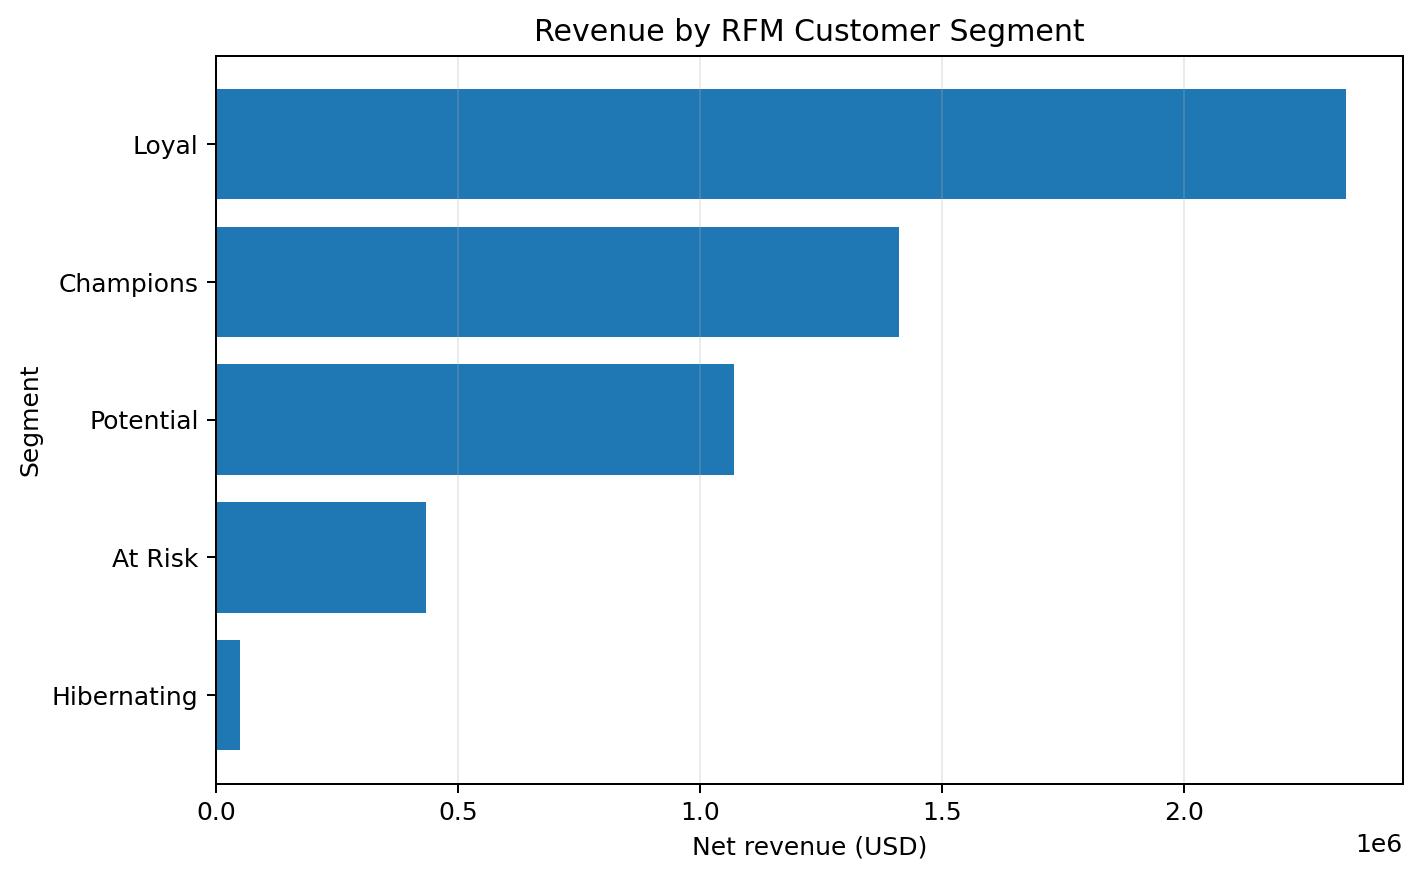

In [20]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / '01_rfm_segment_revenue.png')))

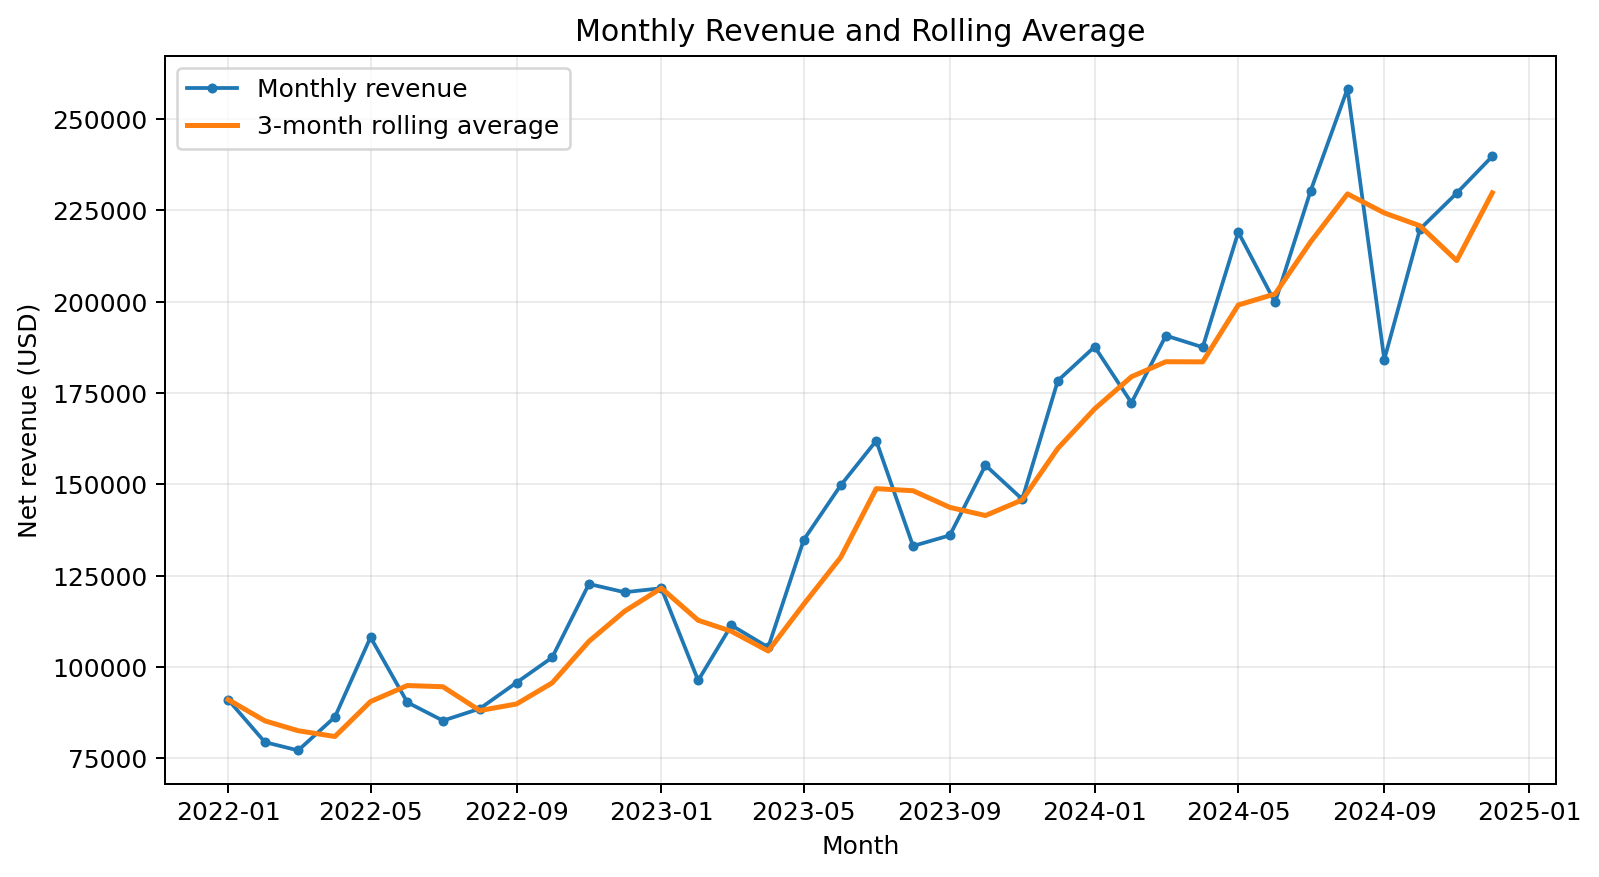

In [21]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / '02_revenue_seasonality.png')))

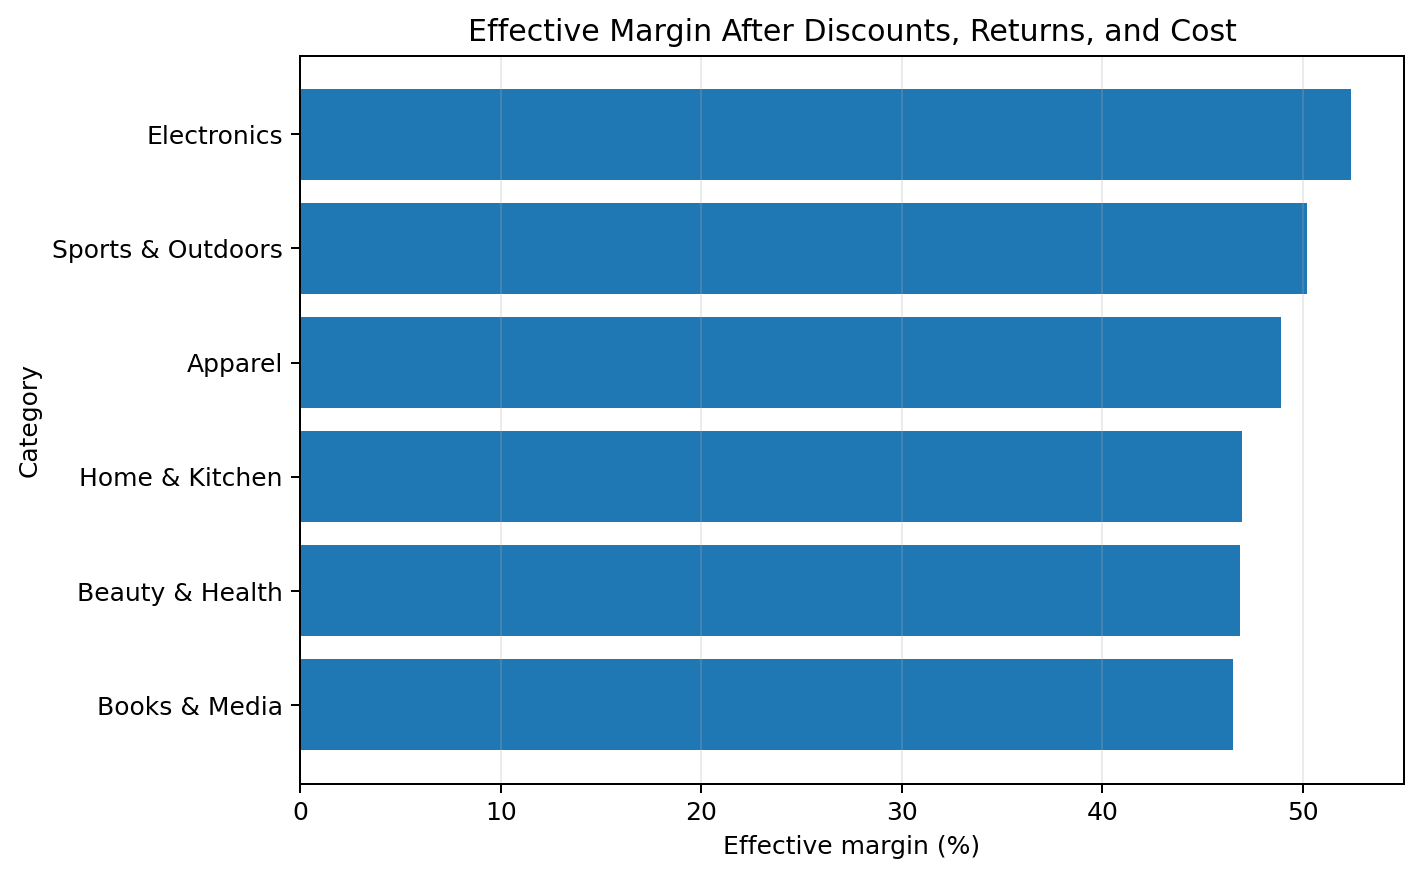

In [22]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / '03_effective_margin_by_category.png')))

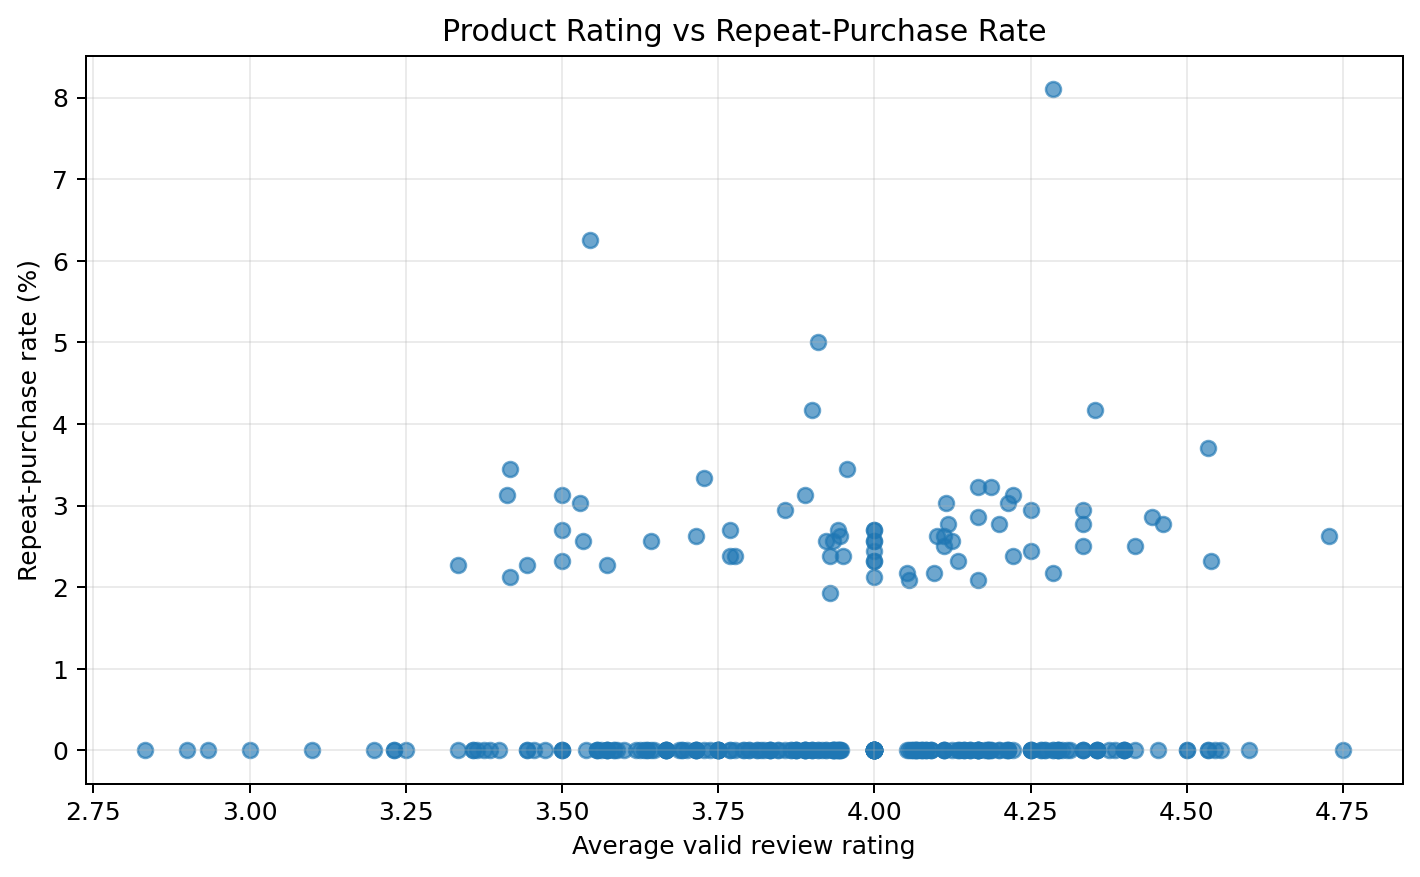

In [23]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / '04_rating_vs_repeat_purchase.png')))

### Business question 5

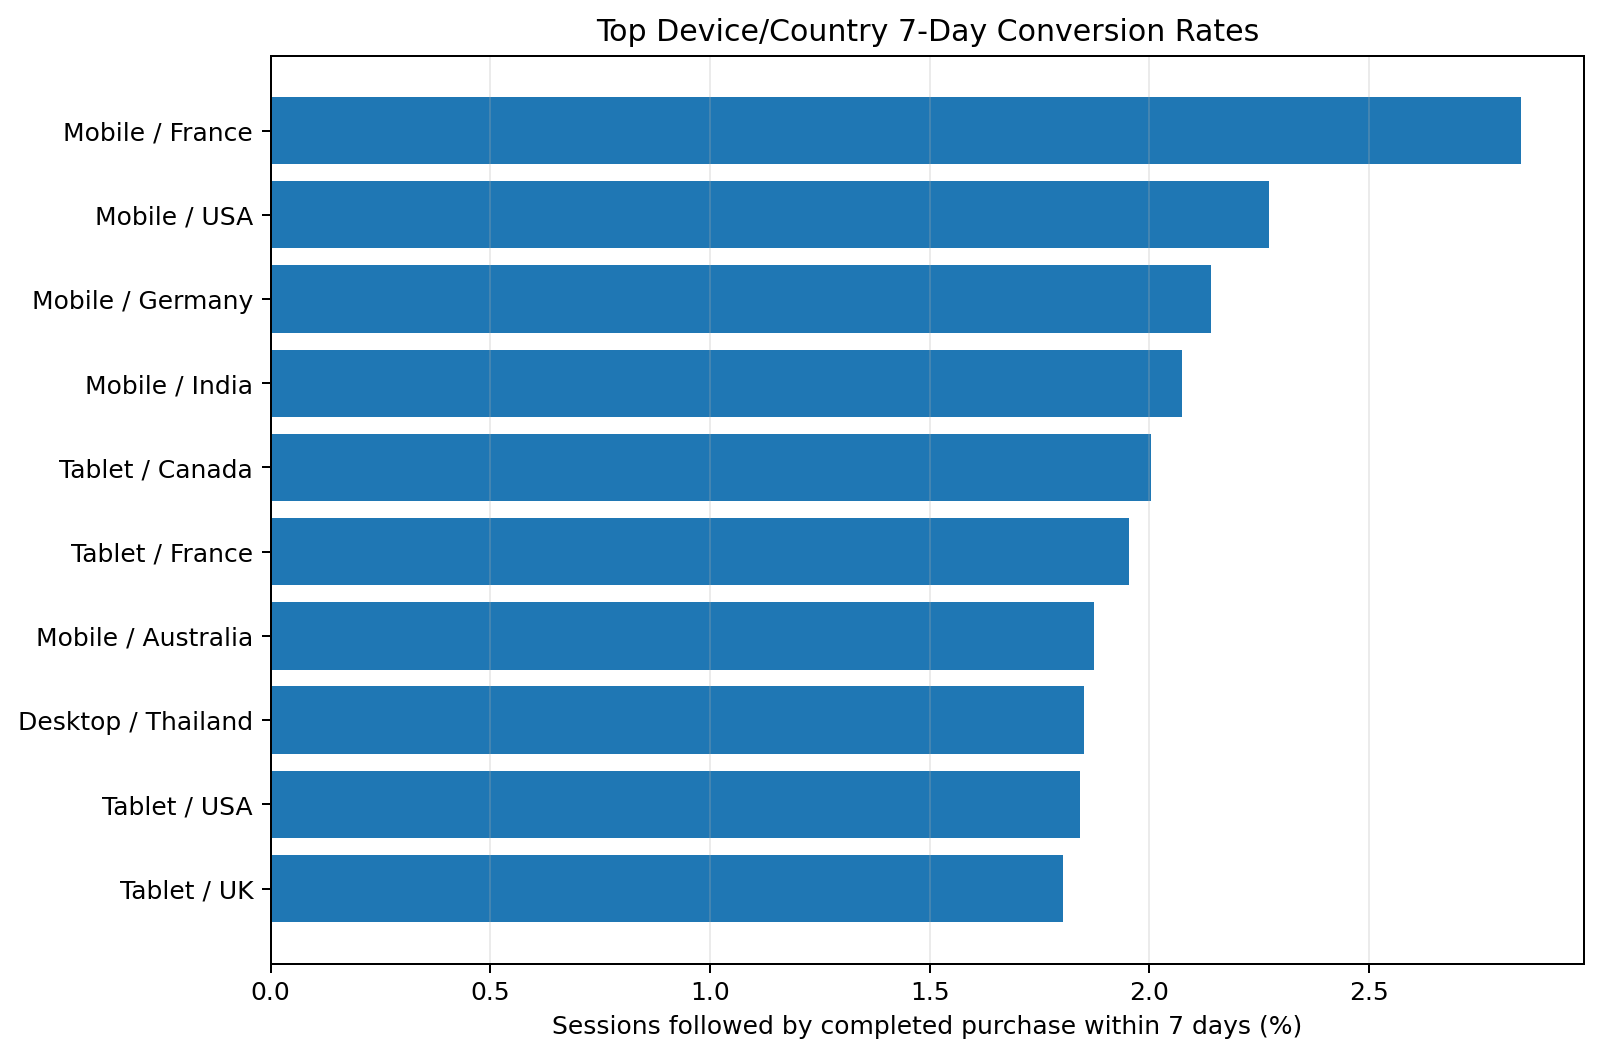

In [24]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / '05_engagement_conversion_device_country.png')))

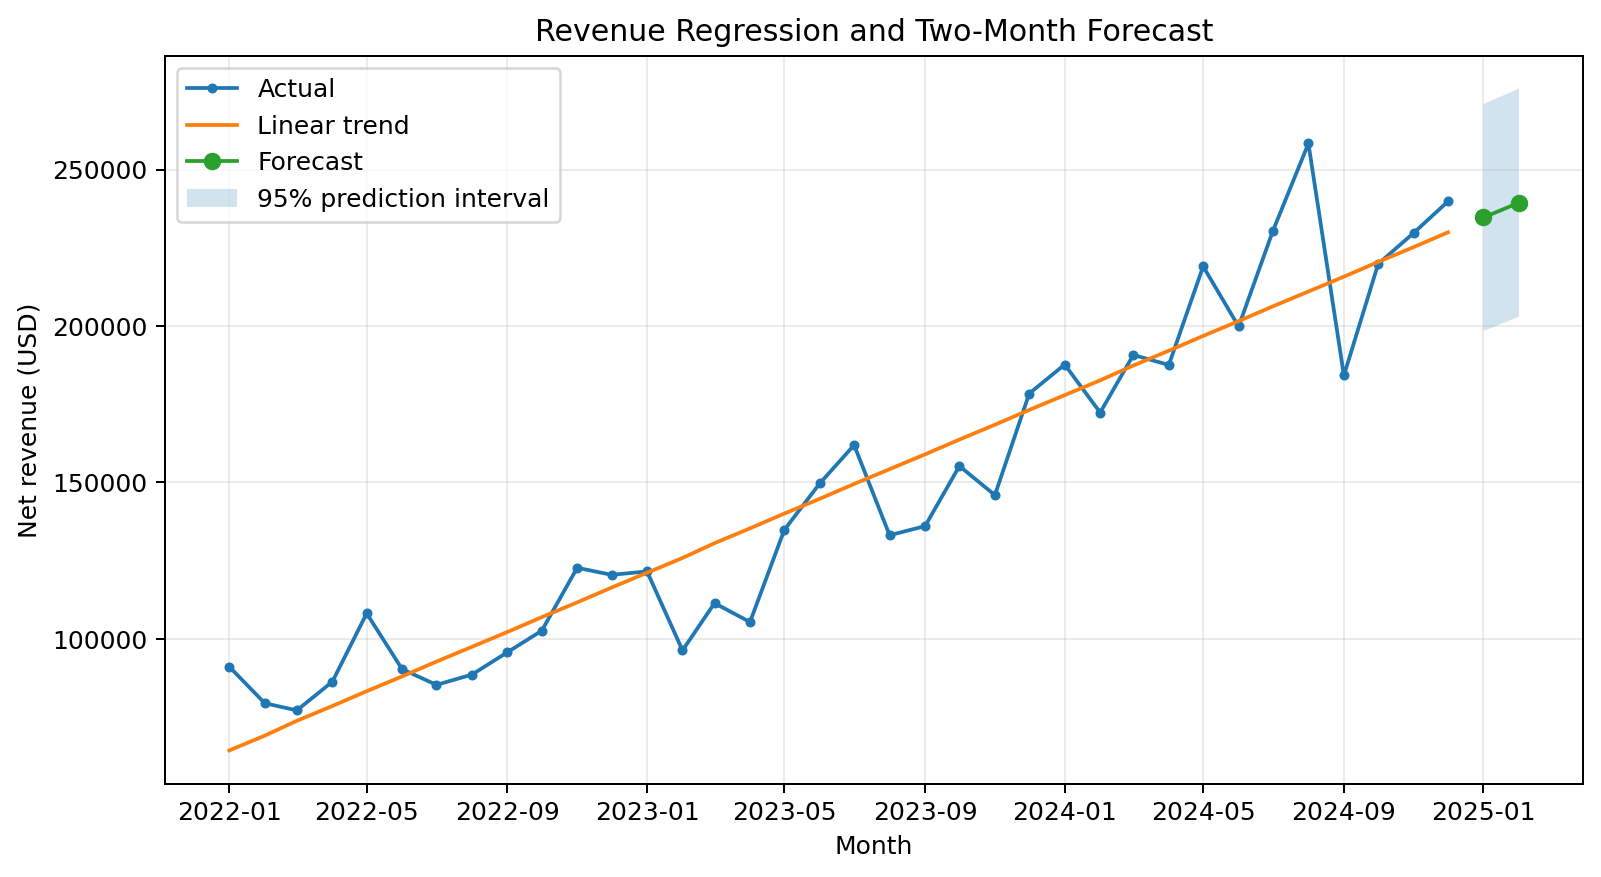

In [25]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / '06_revenue_forecast_next_2_months.png')))

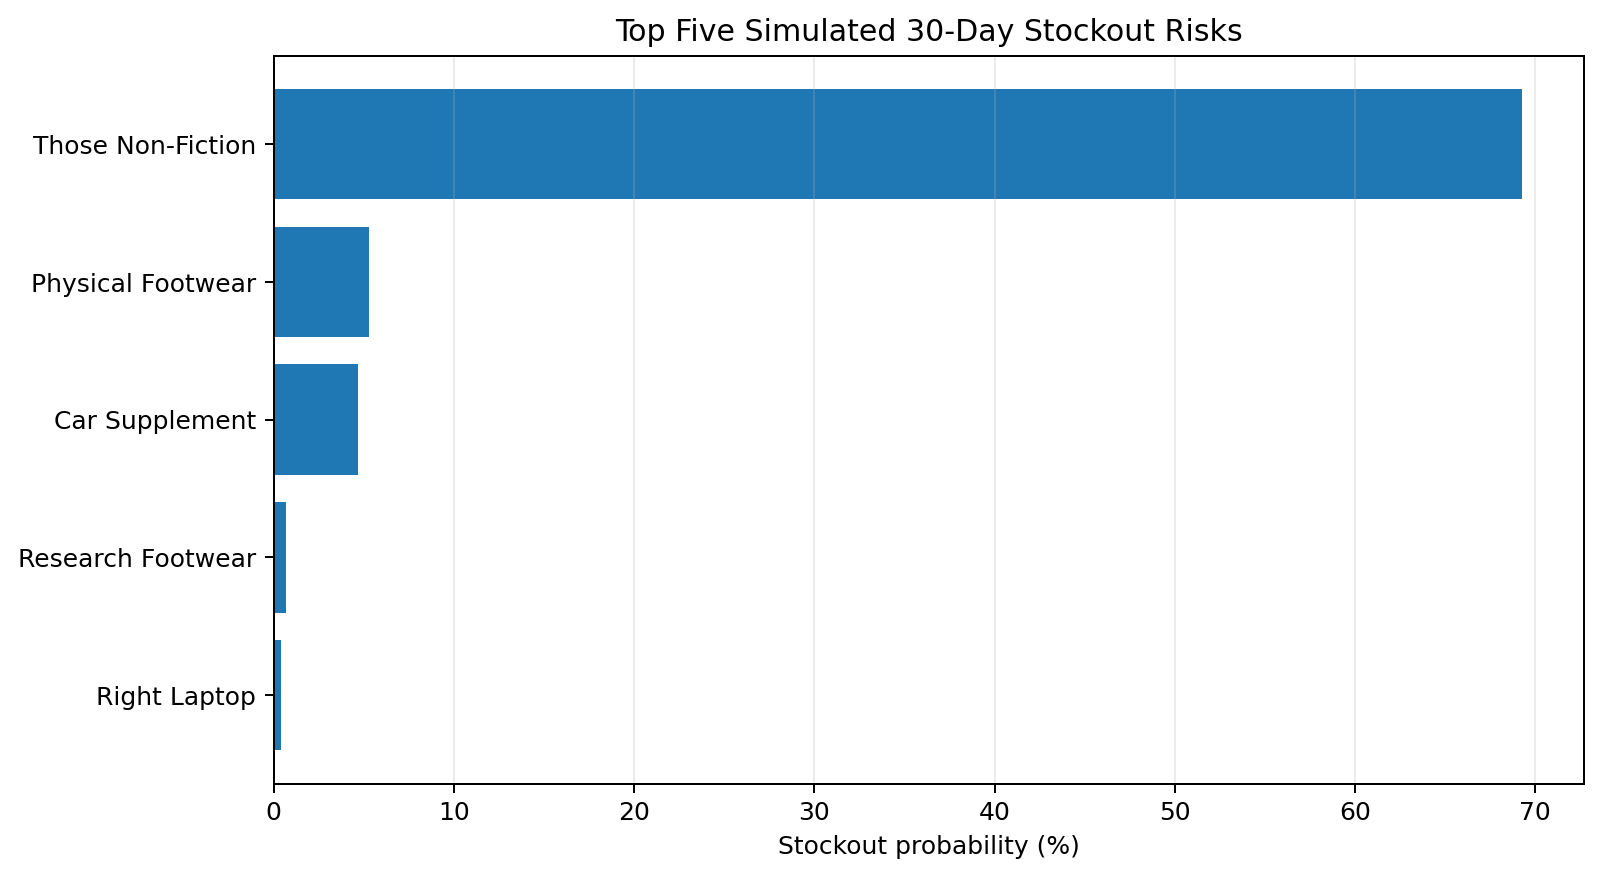

In [26]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / '07_stockout_risk_top5.png')))

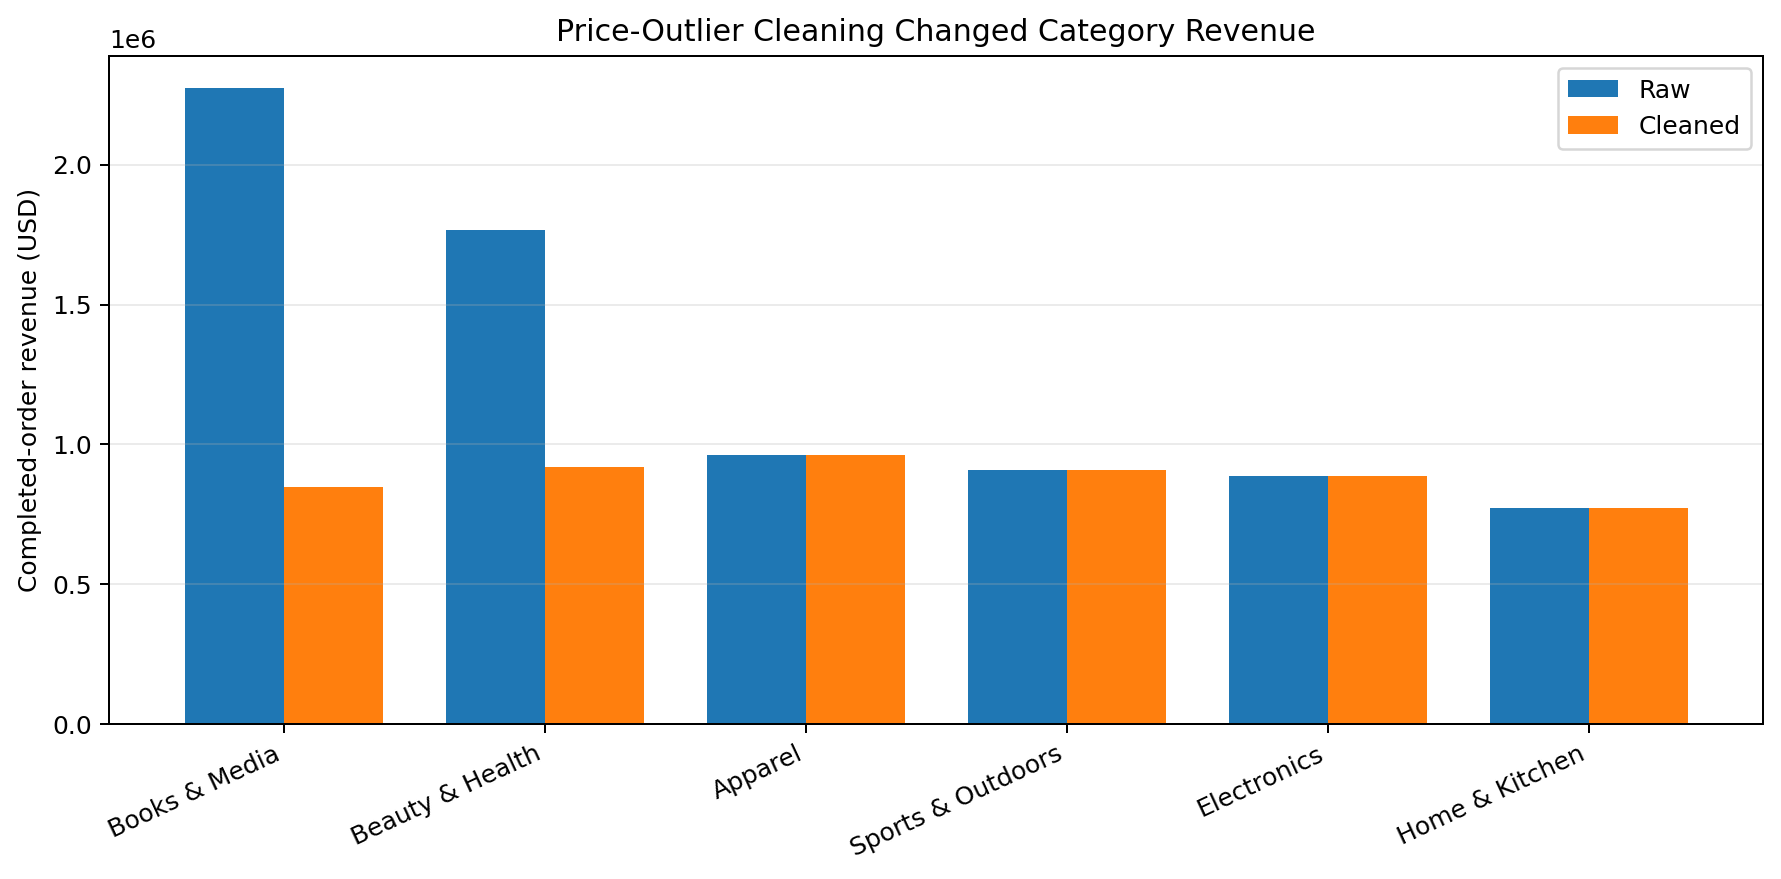

In [27]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / '08_data_quality_impact.png')))